In [1]:
from river import stream 
from river import datasets
from river import tree, ensemble, forest
from river import metrics
from river import compose, preprocessing, linear_model
from river import feature_extraction
from river import drift
from itertools import islice
from river import base
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
metric = metrics.MSE() 
import itertools
from tqdm import tqdm
import pandas as pd
import warnings
import kagglehub
from kagglehub import KaggleDatasetAdapter
from datetime import datetime
import numpy as np
from collections import defaultdict,deque

In [2]:
#%pip install ipywidgets

In [3]:
#%pip install kagglehub

In [4]:
# Na calym datasecie
# Manhattan        921379
# Queens            58774
# Brooklyn          18071
# Bronx               877
# NaN                 855
# Staten Island        44

In [5]:
# %pip install geopandas shapely pyproj pyogrio --no-cache-dir

In [6]:
#%pip install geopy

In [7]:
path = "airports.csv" 

df_airports = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "wenxingdi/data-expo-2009-airline-on-time-data",
  path
)
path2 = "2008.csv" 
df0 = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "wenxingdi/data-expo-2009-airline-on-time-data",
  path2
)

path3="carriers.csv"
df_carriers = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "wenxingdi/data-expo-2009-airline-on-time-data",
  path3
)


In [8]:
us_regions = {
    'South': [
        'TX', 'VA', 'MS', 'FL', 'AR', 'LA', 'OK', 'NC', 
        'KY', 'AL', 'TN', 'MD', 'SC', 'WV', 'GA'
    ],
    'West': [
        'NV', 'CA', 'OR', 'AZ', 'WA', 'UT', 'NM', 'ID', 
        'CO', 'WY', 'HI', 'MT', 'AK'
    ],
    'Midwest': [
        'IN', 'MO', 'IL', 'NE', 'OH', 'MI', 'WI', 'KS', 
        'IA', 'MN', 'SD', 'ND'
    ],
    'Northeast': [
        'NY', 'NH', 'PA', 'RI', 'CT', 'NJ', 'VT', 'ME', 'MA'
    ],
    'Other': [
        'PR', 'VI' 
    ]
}

In [9]:
def previous_flight_features(df):
    df = df.copy()
    
    def hours_transform(time):
        if pd.isna(time):
            return np.nan
        time = int(time)
        hours = time // 100
        mins = time % 100
        t=hours * 60 + mins
        return t

    df['DepTime_mins'] = df['DepTime'].apply(hours_transform)
    df['CRSDepTime_mins'] = df['CRSDepTime'].apply(hours_transform)
    df['CRSArrTime_mins'] = df['CRSArrTime'].apply(hours_transform)
    

    df = df.sort_values(by=['Year', 'Month', 'DayofMonth', 'TailNum', 'DepTime_mins'])
    
    grouping = ['Year', 'Month', 'DayofMonth', 'TailNum']
    
    df['previous_dep_delay'] = df.groupby(grouping)['DepDelay'].shift(1)
    
    df['previous_dep_delay'] = df['previous_dep_delay'].fillna(0)
    
    df['prev_CRSArrTime'] = df.groupby(grouping)['CRSArrTime_mins'].shift(1)
    
    df['scheduled_turnaround'] = df['CRSDepTime_mins'] - df['prev_CRSArrTime']
    
    df['scheduled_turnaround'] = df['scheduled_turnaround'].fillna(60*24)
    
    df = df.drop(columns=['DepTime_mins', 'CRSDepTime_mins', 'CRSArrTime_mins', 'prev_CRSArrTime'])
    df.loc[df['previous_dep_delay'] < 0, 'previous_dep_delay'] = 0
    df.loc[df['DepDelay'] < 0, 'DepDelay'] = 0
    
    return df

df = previous_flight_features(df0)
df

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,previous_dep_delay,scheduled_turnaround
465489,2008,1,1,2,714.0,715,925.0,923,9E,5615,...,0,NaN,0,NaN,NaN,NaN,NaN,NaN,0.0,1440.0
463104,2008,1,1,2,1657.0,1605,1804.0,1650,9E,4722,...,0,NaN,0,0.0,0.0,22.0,0.0,52.0,0.0,402.0
463589,2008,1,1,2,1829.0,1720,1908.0,1812,9E,4743,...,0,NaN,0,0.0,0.0,0.0,0.0,56.0,52.0,30.0
465147,2008,1,1,2,1935.0,1915,2303.0,2252,9E,5601,...,0,NaN,0,NaN,NaN,NaN,NaN,NaN,69.0,63.0
465184,2008,1,1,2,622.0,620,741.0,728,9E,5603,...,0,NaN,0,NaN,NaN,NaN,NaN,NaN,0.0,1440.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2291645,2008,4,30,3,NaN,1255,NaN,1500,AA,1423,...,1,A,0,NaN,NaN,NaN,NaN,NaN,0.0,1440.0
2297180,2008,4,30,3,NaN,620,NaN,1210,AA,1646,...,1,A,0,NaN,NaN,NaN,NaN,NaN,0.0,1440.0
2300746,2008,4,30,3,NaN,1350,NaN,1845,AA,1774,...,1,A,0,NaN,NaN,NaN,NaN,NaN,0.0,1440.0
2343984,2008,4,30,3,NaN,1850,NaN,2323,CO,732,...,1,A,0,NaN,NaN,NaN,NaN,NaN,0.0,1440.0


In [10]:
df["previous_dep_delay"].describe()

count    2.389217e+06
mean     9.095967e+00
std      2.889764e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.000000e+00
max      2.467000e+03
Name: previous_dep_delay, dtype: float64

In [11]:
df["scheduled_turnaround"].describe()

count    2.389217e+06
mean     3.760064e+02
std      5.919194e+02
min     -1.424000e+03
25%      3.100000e+01
50%      5.000000e+01
75%      3.020000e+02
max      1.440000e+03
Name: scheduled_turnaround, dtype: float64

In [12]:
def airline_stream(df):
    
    columns_to_drop = [
        'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay','LateAircraftDelay',
        'TaxiIn', 'TaxiOut', 'ArrDelay', 'DepDelay',  
        'AirTime', 'ActualElapsedTime', 'UniqueCarrier', 
        'ArrTime','Year',
        'CancellationCode','Diverted','Cancelled',
        'FlightNum','TailNum',
        'Origin','Dest'
        
        
    ]
    
    for row in df:
        x = dict(row)
        is_cancelled = int(x.get('Cancelled', 0)) == 1
        is_diverted = int(x.get('Diverted', 0)) == 1
        if is_cancelled or is_diverted:
            continue
            
        y = x.get('ArrDelay')
        for col in columns_to_drop:
            x.pop(col, None)
        
        yield x, y

In [13]:
df_m = df.merge(
    df_airports[['iata', 'state','lat','long']], 
    left_on='Origin', 
    right_on='iata', 
    how='inner'
)
df_m= df_m.rename(columns={'state': 'origin_state','lat':'origin_lat','long':'origin_long'}).drop(columns='iata')


In [14]:
df_merged = df_m.merge(
    df_airports[['iata', 'state','lat','long']], 
    left_on='Dest', 
    right_on='iata', 
    how='inner'
)
df_merged = df_merged.rename(columns={'state': 'dest_state','lat':'dest_lat','long':'dest_long'}).drop(columns='iata')


In [15]:
df_merged.head(5)

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,SecurityDelay,LateAircraftDelay,previous_dep_delay,scheduled_turnaround,origin_state,origin_lat,origin_long,dest_state,dest_lat,dest_long
0,2008,1,1,2,714.0,715,925.0,923,9E,5615,...,NaN,NaN,0.0,1440.0,AR,36.281869,-94.306811,MN,44.880547,-93.216922
1,2008,1,1,2,1657.0,1605,1804.0,1650,9E,4722,...,0.0,52.0,0.0,402.0,MN,44.880547,-93.216922,MN,43.908826,-92.497987
2,2008,1,1,2,1829.0,1720,1908.0,1812,9E,4743,...,0.0,56.0,52.0,30.0,MN,43.908826,-92.497987,MN,44.880547,-93.216922
3,2008,1,1,2,1935.0,1915,2303.0,2252,9E,5601,...,NaN,NaN,69.0,63.0,MN,44.880547,-93.216922,NC,36.097747,-79.937297
4,2008,1,1,2,622.0,620,741.0,728,9E,5603,...,NaN,NaN,0.0,1440.0,IA,41.534933,-93.660682,MN,44.880547,-93.216922


In [16]:
rows = df_merged.to_dict(orient='records')
data = airline_stream(rows)

full_stream=data
x, y = next(data)
print(x)
print(y)


{'Month': 1, 'DayofMonth': 1, 'DayOfWeek': 2, 'DepTime': 714.0, 'CRSDepTime': 715, 'CRSArrTime': 923, 'CRSElapsedTime': 128.0, 'Distance': 596, 'previous_dep_delay': 0.0, 'scheduled_turnaround': 1440.0, 'origin_state': 'AR', 'origin_lat': 36.28186944, 'origin_long': -94.30681111, 'dest_state': 'MN', 'dest_lat': 44.88054694, 'dest_long': -93.2169225}
2.0


In [17]:
x, y = next(iter(data))
x

{'Month': 1,
 'DayofMonth': 1,
 'DayOfWeek': 2,
 'DepTime': 1657.0,
 'CRSDepTime': 1605,
 'CRSArrTime': 1650,
 'CRSElapsedTime': 45.0,
 'Distance': 76,
 'previous_dep_delay': 0.0,
 'scheduled_turnaround': 402.0,
 'origin_state': 'MN',
 'origin_lat': 44.88054694,
 'origin_long': -93.2169225,
 'dest_state': 'MN',
 'dest_lat': 43.90882639,
 'dest_long': -92.49798722}

In [18]:
class FeatureDistrict(base.Transformer):
    
    def get_region(self, state_code):
        for region, states in us_regions.items():
            if state_code in states:
                return region
        return 'none'
      
    def transform_one(self, x):
        x = x.copy()
        
        pickup_d = self.get_region(x["origin_state"])
        dropoff_d = self.get_region(x["dest_state"])

        x["pickup_district"] = pickup_d
        x["dropoff_district"] = dropoff_d

        x["within_district"] = int(
            pickup_d == dropoff_d and pickup_d != "Other" and pickup_d !="none" 
        )

        x["is_weekend"] = int(x["DayOfWeek"] > 5)
        
        month = int(x["Month"])
        day = int(x["DayofMonth"])
        h=int(x["CRSDepTime"]//100)
        min=x["CRSDepTime"]
        x["timestamp"] = datetime(2008,month, day,h)
        
        columns_to_drop=["Month","DayofMonth","DayOfWeek","origin_state","dest_state","DepTime"]
        for col in columns_to_drop:
            x.pop(col, None)
            

        return x

In [19]:
transformer = FeatureDistrict()
x_2 = transformer.transform_one(x)
x_2

{'CRSDepTime': 1605,
 'CRSArrTime': 1650,
 'CRSElapsedTime': 45.0,
 'Distance': 76,
 'previous_dep_delay': 0.0,
 'scheduled_turnaround': 402.0,
 'origin_lat': 44.88054694,
 'origin_long': -93.2169225,
 'dest_lat': 43.90882639,
 'dest_long': -92.49798722,
 'pickup_district': 'Midwest',
 'dropoff_district': 'Midwest',
 'within_district': 1,
 'is_weekend': 0,
 'timestamp': datetime.datetime(2008, 1, 1, 16, 0)}

In [20]:

def createShadow():
     return forest.ARFRegressor(n_models=12, seed=0)


In [21]:
def models_dist(district):
    #scaler = preprocessing.StandardScaler()
    if district == "South":
        #model = forest.ARFRegressor(n_models=10, seed=0)
        model = ensemble.SRPRegressor(n_models=10, seed=0)
    elif district == "West":
        model = ensemble.SRPRegressor(n_models=10, seed=0)
    elif district == "Midwest":
        model = ensemble.SRPRegressor(n_models=10, seed=0)
         #model = forest.ARFRegressor(n_models=13, seed=0)
    elif district == "Northeast":
        model = ensemble.SRPRegressor(n_models=13, seed=0)
    elif district == "Global":
        model = forest.ARFRegressor(n_models=10, seed=0)
    return model


districts = ["South", "West","Midwest", "Northeast", "Global"]
models = {d: models_dist(d) for d in districts}
shadow_models = {d: None for d in districts}

In [22]:
adwin_configs = {
    "South": {"delta": 0.0001},    
    "West": {"delta": 0.005},      
    "Midwest": {"delta": 0.001},  
    "Northeast": {"delta": 0.002}, 
    "Global": {"delta": 0.01}      
}
drift_detectors = {d: drift.ADWIN(delta=adwin_configs[d]["delta"], grace_period=7000) for d in districts}
warning_detectors = {d: drift.ADWIN(delta=0.1) for d in districts}
# warning_detectors = {d: drift.KSWIN(alpha=0.05) for d in districts}

In [23]:
configs = {
    "South": {"window_size": 200, "stat_size": 50, "alpha": 0.001},
    "West": {"window_size": 200, "stat_size": 50, "alpha": 0.005},
    "Midwest": {"window_size": 100, "stat_size": 30, "alpha": 0.002},
    "Northeast": {"window_size": 300, "stat_size": 20, "alpha": 0.001},

    "Global": {"window_size": 100, "stat_size": 30, "alpha": 0.01}

}


distribution_detectors = {
    d: drift.KSWIN(
        window_size=params["window_size"],
        stat_size=params["stat_size"],
        alpha=params["alpha"]
    )
    for d, params in configs.items()
}

In [24]:
# distribution_detectors

In [25]:
# x, y = next(iter(data))

# timestamp = x["pickup_datetime"]

# x = transformer.transform_one(x)
# if x["within_district"] == 1:
#     district = x["pickup_district"]
# else:
#     district="Global"
# x.pop("pickup_district",None)
# x.pop("pickup_district",None)
# x


In [26]:
def centroid(X):
    if len(X) == 0:
        return None
    return np.mean(X, axis=0)
    
def centroid_distance(c1, c2):
    return np.linalg.norm(c1 - c2) #sprawdzic inna Mahalanobis?
centroid_windows = []
centroid_drift_log = defaultdict(list)
centroid_adwin = {d: drift.ADWIN(delta=0.007) for d in districts}

daily_errors = defaultdict(lambda: defaultdict(list))

In [27]:
local_counts = {d: 0 for d in districts}

#zmienne do rmse
window_size = 50  
error_windows = defaultdict(list)
window_rmse_series = defaultdict(lambda: defaultdict(list))
time_series = defaultdict(list)

#zmienne do dryftu 
drift_timestamps = {d: [] for d in districts}
drift_instances = {d: [] for d in districts}  

kswin_timestamps = {d: [] for d in districts}
kswin_instances = {d: [] for d in districts}  

# window_size = 200 
# error_series = {d: [] for d in districts}     

# window_error = {d: [] for d in districts}
# window=100
# time_series = {d: [] for d in districts}

# drift_dist_t={d: [] for d in districts}



In [28]:
s=1000000 #5 min dla 300000 sample

transformer = FeatureDistrict()
stream = itertools.islice(full_stream, s)

In [29]:
for x, y in tqdm(stream, total=s, desc="Done"):

    x = transformer.transform_one(x)
    #timestamp = x["timestamp"]
    timestamp = pd.to_datetime(x["timestamp"])
    date = timestamp.date()
    
    x.pop("timestamp",None)
    
    if x["within_district"] == 1:
        district = x["pickup_district"]
    else:
        district="Global"
    x.pop("pickup_district",None)
    x.pop("dropoff_district",None)
    
    model = models[district]
    
    y_pred = model.predict_one(x)
    local_counts[district] += 1
    instanceCount = local_counts[district]
    
    if y_pred is not None:
        if y_pred<=0:
            y_pred=0
            
        msa=abs(y_pred - y)
        daily_errors[district][date].append(msa)
        error = (y_pred - y) ** 2
        error_windows[district].append(error)
        if len(error_windows[district]) > window_size:
            error_windows[district].pop(0)

        if len(error_windows[district]) == window_size:
            rmse = np.sqrt(sum(error_windows[district]) / window_size)
            # if instanceCount % 10 == 0:
            window_rmse_series[district][timestamp].append(rmse)
            #time_series[district].append(timestamp)

        

        drift=drift_detectors[district]
        drift.update(error)
        
        distribution_detect=distribution_detectors[district]
        distribution_detect.update(x["previous_dep_delay"])
        
        if instanceCount > 2000:
           # if distribution_detect.drift_detected:
                #print(f"DISTRIBUTION SHIFT DRIFT DETECTED in {district} at count:{instanceCount}")
                #drift_dist_timestamps[district].append(timestamp)
                
            if distribution_detect.drift_detected:
                kswin_instances[district].append(local_counts[district])
                kswin_timestamps[district].append(timestamp)
        
                if shadow_models[district] is None:
                    print(f"WARNING in {district} at count:{instanceCount}")
                    shadow_models[district] = createShadow()
                    shadow_models[district].learn_one(x,y)
                else: 
                    shadow_models[district].learn_one(x,y)
                
    
            if drift.drift_detected:
                print(f"DRIFT DETECTED in {district} at count:{instanceCount}")
                
                drift_instances[district].append(local_counts[district])
                drift_timestamps[district].append(timestamp)
                
                if shadow_models[district] is not None:
                    models[district] = shadow_models[district]
                    shadow_models[district] = None 
                    models[district].learn_one(x,y) 
               # else: models[district] = createShadow()

        #Centroid jaki detector?
        # feature_vec = np.array(list(x.values()), dtype=float)
        # centroid_windows[district].append(feature_vec)
        
        # if len(centroid_windows[district]) == window:
        
        #     current_centroid = centroid(centroid_windows[district])
        
        #     if district not in centroid_ref:
        #         centroid_ref[district] = current_centroid
        #     else:
        #         dist = centroid_distance(current_centroid, centroid_ref[district])
        #         centroid_adwin[district].update(dist)
        
        #         if centroid_adwin[district].drift_detected:
        #             #print(f"CENTROID DRIFT DETECTED in {district} at {instanceCount}")
        #             centroid_drift_log[district].append({
        #                 "time": timestamp,
        #                 "instance": instanceCount
        #             })
        
                # centroid_ref[district] = current_centroid


    model.learn_one(x, y)
    

Done:   0%|          | 4481/1000000 [00:08<36:35, 453.37it/s]

WARNING in Global at count:2058


Done:   1%|          | 9658/1000000 [00:17<26:25, 624.63it/s]  

WARNING in West at count:2102


Done:   1%|▏         | 14725/1000000 [00:27<33:59, 483.21it/s]

...

Done:  99%|█████████▉| 988579/1000000 [53:14<01:25, 133.54it/s]

WARNING in Northeast at count:19774


Done: 100%|█████████▉| 999294/1000000 [54:03<00:03, 216.76it/s]

DRIFT DETECTED in West at count:225568


Done: 100%|██████████| 1000000/1000000 [54:06<00:00, 308.02it/s]


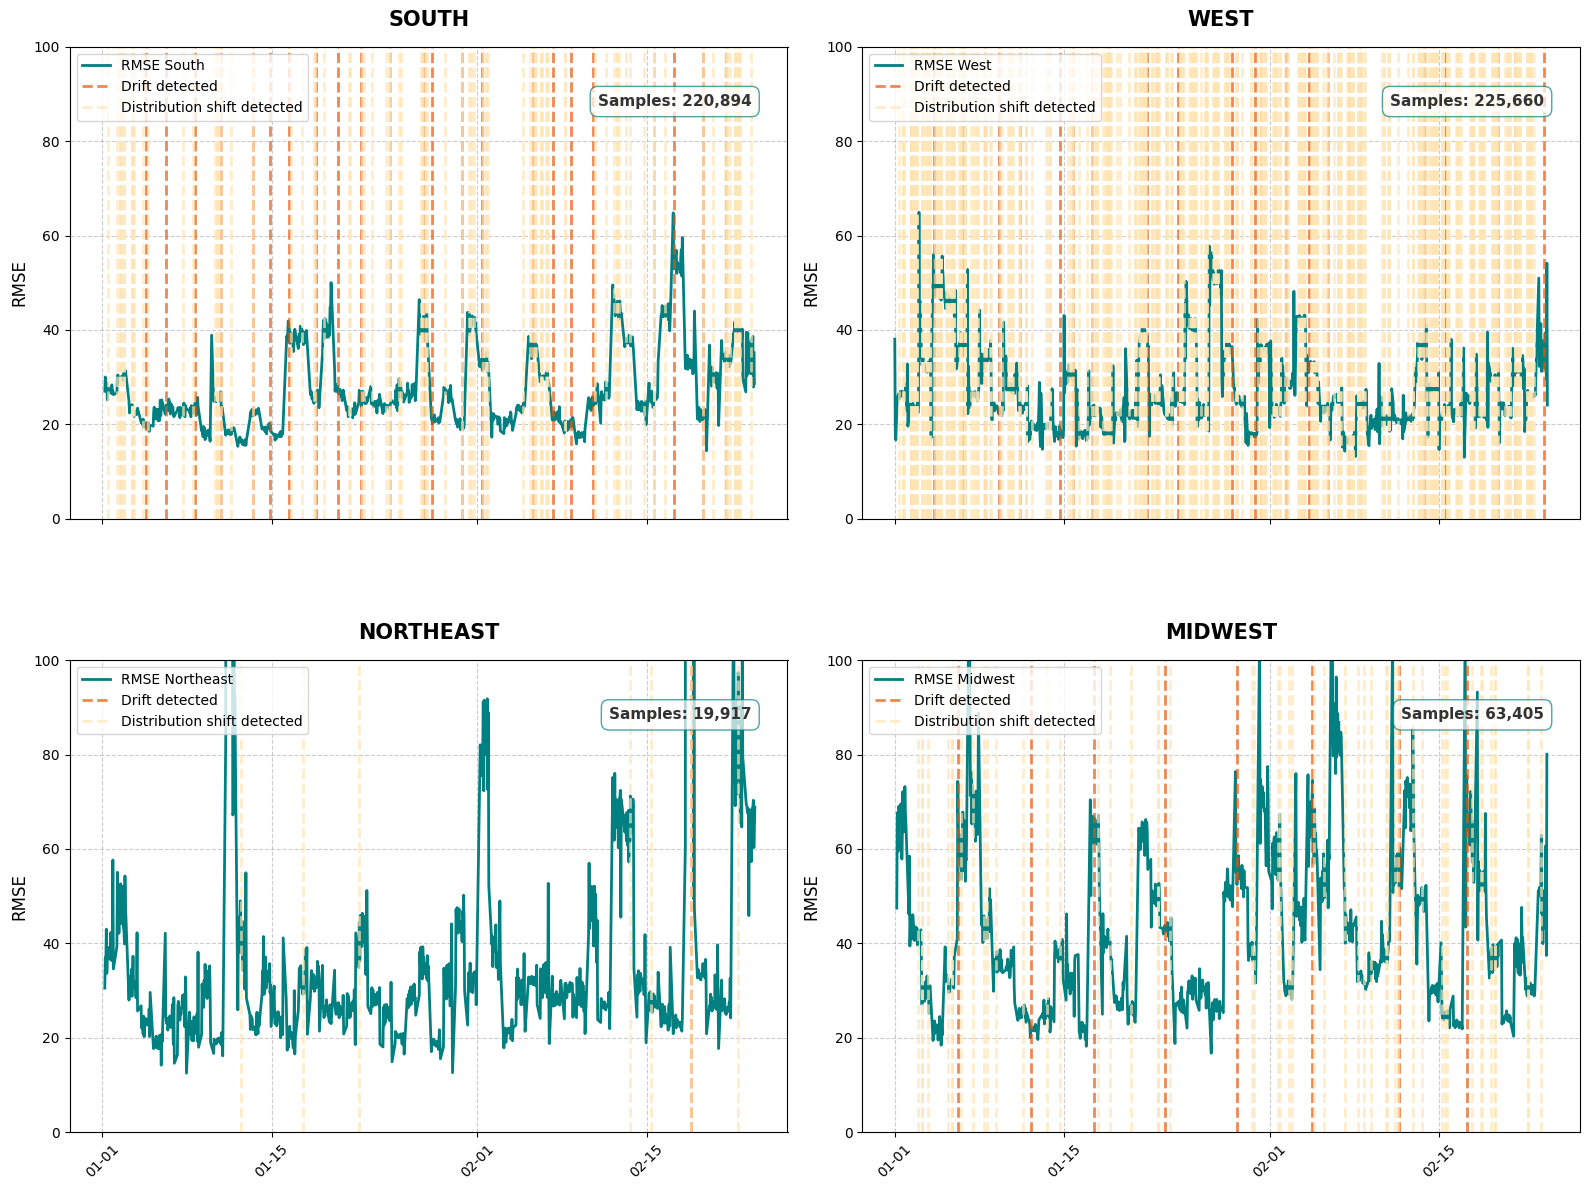

In [30]:

district_list = ["South", "West", "Northeast", "Midwest"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for ax, dist in zip(axes, district_list):

    df = pd.DataFrame([
        (t, rmse)
        for t, values in window_rmse_series[dist].items()
        for rmse in values
    ], columns=["time", "rmse"])
    
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time")
    
    df_mean = df.groupby("time")["rmse"].mean()
    df_std = df.groupby("time")["rmse"].std()
    
    line_ref = ax.plot(
        df_mean.index,
        df_mean.values,
        color='#008080',
        linewidth=2,
        label=f"RMSE {dist}"
    )[0]


    color = line_ref.get_color()
    count = local_counts.get(dist, 0)

    ax.text(
        0.95, 0.90, f"Samples: {count:,}",
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor='white',
                  alpha=0.7,
                  edgecolor=color),
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )

    if dist in drift_timestamps:
        for i, t in enumerate(drift_timestamps[dist]):
            ax.axvline(
                pd.to_datetime(t),
                color="#EB5406",
                linestyle='--',
                linewidth=2,
                alpha=0.7,
                label="Drift detected" if i == 0 else ""
            )

    if dist in kswin_timestamps:
        for i, t in enumerate(kswin_timestamps[dist]):
            ax.axvline(
                pd.to_datetime(t),
                color="#FFE5B4",
                linestyle='--',
                linewidth=2,
                alpha=0.7,
                label="Distribution shift detected" if i == 0 else ""
            )

    ax.set_title(dist.upper(), fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel("RMSE", fontsize=12)

    ax.grid(True, linestyle='--', alpha=0.4, color='gray')

    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    ax.tick_params(axis='x', rotation=45, labelsize=10)

    ax.legend(loc='upper left', frameon=True, facecolor='white')
    ax.set_ylim(0, 100)
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.savefig('Airlines.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:

# dist = "Global"
# fig, ax = plt.subplots(figsize=(12, 6))


# errors = day_rmse.get(dist, [])
# times = time_series.get(dist, [])

# df_plot = pd.DataFrame({
#     "time": times,
#     "error": errors
# }).sort_values("time")

# time_plot = df_plot["time"]
# error_plot = df_plot["error"]


# line_ref = ax.plot(
#     time_plot,
#     error_plot,
#     label=f"Daily error {dist}",
#     linewidth=2
# )[0]

# color = line_ref.get_color()

# count = local_counts.get(dist, 0) 

# # Pole tekstowe z liczbą próbek
# ax.text(0.95, 0.90, f"Samples: {count:,}", 
#         transform=ax.transAxes, 
#         verticalalignment='top', 
#         horizontalalignment='right',
#         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7, edgecolor=color),
#         fontsize=11, fontweight='bold', color='#333333')


# if dist in drift_timestamps:
#     for i, t in enumerate(drift_timestamps[dist]):
#         lbl = "Drift detected" if i == 0 else ""
#         ax.axvline(
#             pd.to_datetime(t),
#             color="red", 
#             linestyle='--',
#             linewidth=2,
#             alpha=0.7,
#             label=lbl
#         )

# if dist in centroid_drift_log:
#     for i, t in enumerate(centroid_drift_log[dist]):
#         lbl = "Distribution shift detected" if i == 0 else ""
        
#         drift_time = pd.to_datetime(t["time"]) 
        
#         ax.axvline(
#             x=drift_time,
#             color="#FFE5B4", 
#             linestyle='--',
#             linewidth=2,
#             alpha=0.7,
#             label=lbl
#         )


# ax.set_title(dist.upper(), fontsize=15, fontweight='bold', pad=15)
# ax.set_ylim(0, 100)
# ax.set_ylabel("RMSE", fontsize=12)

# ax.grid(True, which='major', linestyle='--', alpha=0.4, color='gray')

# ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# ax.tick_params(axis='x', rotation=45, labelsize=10)


# if (dist in drift_timestamps) or (dist in centroid_drift_log):
#     ax.legend(loc='upper left', frameon=True, facecolor='white')

# plt.tight_layout()

# plt.savefig('Airlines_Global.png', dpi=300, bbox_inches='tight') 
# plt.show()